## Parte 1: Exploración

In [5]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Advertising.csv')
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [6]:
df.corr()

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000000,0.017715,-0.110680,-0.154944,-0.051616
TV,0.017715,1.000000,0.054809,0.056648,0.782224
Radio,-0.110680,0.054809,1.000000,0.354104,0.576223
Newspaper,-0.154944,0.056648,0.354104,1.000000,0.228299
Sales,-0.051616,0.782224,0.576223,0.228299,1.000000


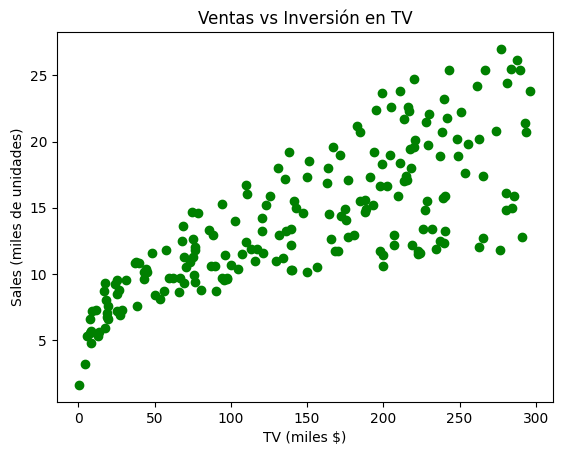

In [14]:
import matplotlib.pyplot as plt
plt.scatter(df['TV'], df['Sales'], color = 'green')
plt.xlabel('TV (miles $)')
plt.ylabel('Sales (miles de unidades)')
plt.title('Ventas vs Inversión en TV')
plt.show()

En la exploración, TV tiene un rango aproximado de 0.7 a 296.4 y Sales de 1.6 a 27.0; no se observan outliers extremos claros, aunque hay algunos puntos con TV alta y ventas relativamente bajas que podrían ser variación natural del fenómeno. La correlación TV–Sales es positiva y fuerte (≈0.78), y el scatter plot muestra una relación mayormente lineal y creciente, con algunos puntos alejados del patrón general pero sin alterar la tendencia principal.

## Parte 2

### 2A. Implementación desde cero con numpy
Calcula los coeficientes manualmente usando las fórmulas cerradas (OLS).

In [8]:
import numpy as np

X = df['TV'].values
Y = df['Sales'].values
X_mean = np.mean(X)
Y_mean = np.mean(Y)

numerator = np.sum((X - X_mean) * (Y - Y_mean))
denominator = np.sum((X - X_mean)**2)
beta_1 = numerator / denominator
beta_0 = Y_mean - beta_1 * X_mean

print(f'beta_0 = {beta_0:.3f}')
print(f'beta_1 = {beta_1:.3f}')

beta_0 = 7.033
beta_1 = 0.048


### 2B. Implementación con scikit-learn
Ahora repite usando la librería profesional (los coeficientes deben ser muy parecidos).

In [9]:
from sklearn.linear_model import LinearRegression

X = df[['TV']]
y = df['Sales']
model = LinearRegression()
model.fit(X, y)

print(f'Intercepto: {model.intercept_:.3f}')
print(f'Pendiente: {model.coef_[0]:.3f}')

y_pred = model.predict(X)

Intercepto: 7.033
Pendiente: 0.048


### 2C. Calcular métricas

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y, y_pred)

print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

MSE: 10.513
RMSE: 3.242
R²: 0.612


## Parte 3: Visualización

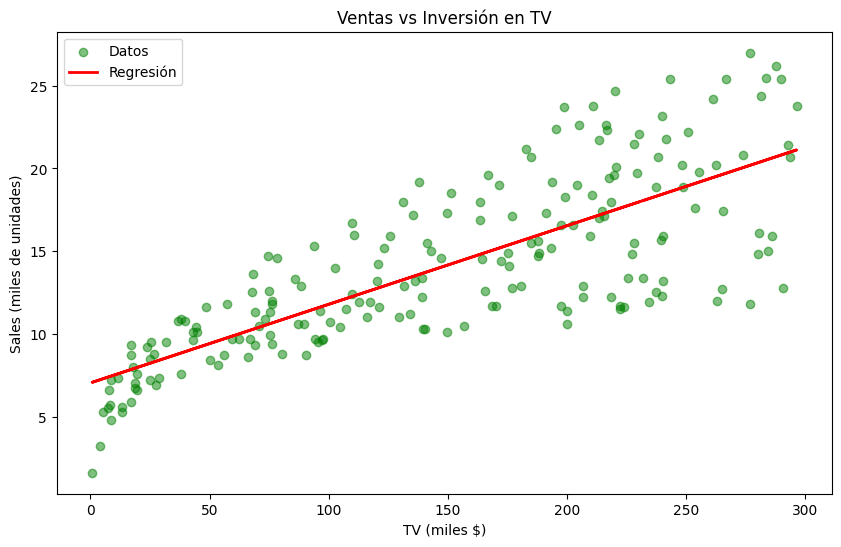

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Datos', color = 'green')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regresión')
plt.xlabel('TV (miles $)')
plt.ylabel('Sales (miles de unidades)')
plt.legend()
plt.title('Ventas vs Inversión en TV')
plt.show()

### 3.2 Gráfico de residuos
Busca lo siguiente: patrón aleatorio alrededor de cero (buena señal), patrón curvo (problema de linealidad), forma de embudo (heterocedasticidad).

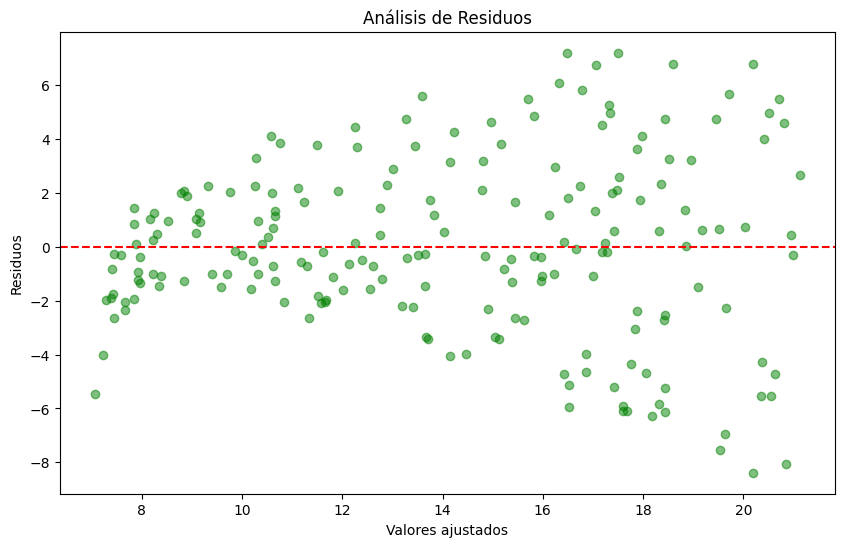

In [16]:
# Calcular residuos
residuals = y - y_pred

# Gráfico de residuos vs predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color = 'green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos')
plt.title('Análisis de Residuos')
plt.show()

### 3.3 Q-Q Plot

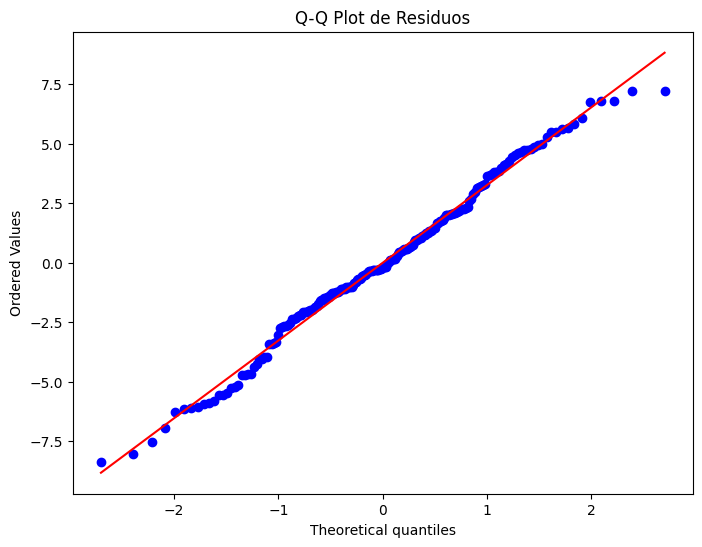

In [21]:
import scipy.stats as stats

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot de Residuos')
plt.show()

## Parte 4: Interpretación
Resultados esperados del modelo:

$${Sales} = 7.03 + 0.048 \times {TV}$$

**¿Qué significa $\beta_0 = 7.03$?** \
Son las ventas esperadas cuando la inversión en TV es $0$: $7.03$ mil unidades.

**¿Qué significa $\beta_1 = 0.048$?** \
Por cada $1$ mil dólares adicionales en TV, las ventas esperadas suben $0.048$ mil unidades (≈ $48$ unidades).

**Si inviertes 100 mil dólares más en TV, ¿cuántas ventas adicionales esperas?** \
$0.048 \times 100 = 4.8$ mil unidades (≈ $4{,}800$ unidades).

**$R^2 = 0.61$. ¿Es bueno o malo?** \
El modelo explica ~$61\%$ de la variabilidad en ventas y queda ~$39\%$ sin explicar, se podría considerar como un ajuste moderado.

**¿Recomendarías invertir más en TV basándote solamente en este análisis?** \
No, faltan considerar otras variables, costos y factores adicionales.